# LangGraph 101：构建你的第一个 Agent

<img src="../../images/react_agent.png" style="width: auto; max-height: 500px; border-radius: 8px;">

欢迎来到 LangGraph 101！这个 notebook 会带你了解如何使用 LangChain 和 LangGraph 构建 Agent 的核心概念。

**你将学到：**
- 如何与语言模型交互
- 如何使用消息和多轮对话
- 如何添加工具来扩展 LLM 能力
- 如何构建一个可以推理和行动的 Agent
- 如何添加记忆以保留上下文
- 如何用流式输出改善用户体验
<br> 
<br> 
---
<br> 

> **注意：** 本教程使用 LangChain v1（alpha），它提供了开始构建 LLM 应用的便捷方式。LangChain Agent 构建在 LangGraph 之上，开箱即支持持久执行、流式输出、人在回路和持久化能力。


## 第 0 部分：环境准备与安装

首先，我们安装必要的依赖包并配置运行环境。


In [1]:
# 安装所需依赖包
# 可以运行 uv sync 安装依赖，或运行：
# !pip install --pre -U langchain langchain-anthropic langchain-openai python-dotenv


### 初始化你的 LLM

In [2]:
# 将项目根目录添加到 Python 路径，方便从 utils 模块导入
import sys 
from pathlib import Path 
project_root =Path ().resolve ().parent .parent 
if str (project_root )not in sys .path :
    sys .path .insert (0 ,str (project_root ))

    # 从统一的 utils 模块导入模型
    # 这样可以避免 notebook 之间重复代码，并保持模型配置一致
from utils .models import model 

# 备选方案：如果想在当前 notebook 中直接定义模型，而不是使用统一配置，可以取消下面几行注释：
# 从 dotenv 导入 load_dotenv
# load_dotenv(dotenv_path="../.env", override=True)
# 从 langchain.chat_models 导入 init_chat_model
# 模型 = init_chat_model("openai:o3-mini")

# 注意：如果使用其他供应商（Azure、Bedrock、Vertex AI），请更新 utils/models.py
# 切换 LLM 供应商的详细说明见 utils/models.py


# 对没有 thread id 的简单示例，忽略 uuid v7 相关警告
import warnings 
warnings .filterwarnings ('ignore',message ='LangSmith 现在使用 UUID v7')


## 第 1 部分：第一次 LLM 调用

LangChain 提供了一个适用于各类模型供应商的**标准模型接口**。这意味着你可以在 OpenAI、Anthropic、Google 以及其他供应商之间轻松切换，而不需要修改业务代码。

我们先从初始化一个聊天模型开始。


In [3]:
# 第一次调用模型！
response =model .invoke ('什么是 LangChain？')
response .pretty_print ()


================================== Ai Message ==================================

LangChain是一个用于开发大语言模型（LLM）应用的**开源框架**。它的核心理念是**将LLM与外部数据源、工具和逻辑进行组合和编排**，帮助开发者构建更复杂、更强大的应用程序。

简单来说，如果你把GPT、文心一言这些大模型比作一个“强大的大脑”，那么LangChain就是让这个大脑能够“动手做事”的“身体和工具”。它解决了单纯调用大模型API时的一些关键痛点：

### 核心要解决的问题

1.  **数据时效性**：大模型的知识有截止日期，无法知晓最新信息。
2.  **内部知识访问**：大模型无法访问公司内部文档、数据库或用户的私有数据。
3.  **执行操作**：大模型只能生成文本，无法直接发送邮件、查询数据库、调用外部API或控制设备。
4.  **长时记忆**：大多数API调用是无状态的，每次对话都是独立的，模型记不住之前聊了什么。

### LangChain的主要特性

1.  **组件化（Components）**：它将LLM应用开发中的常见任务抽象成标准化的模块，比如：
    -   **模型（Models）**：对接各种LLM（如OpenAI、Anthropic、HuggingFace等）。
    -   **提示词（Prompts）**：管理和优化输入给模型的文本。
    -   **数据连接（Data Connection）**：连接外部数据源（如PDF、网页、数据库），进行文档加载、分割、向量化存储和检索。
    -   **记忆（Memory）**：管理对话历史，让模型具有短期和长期记忆。
    -   **代理（Agents）**：让LLM能够根据用户意图，**自主决定**调用哪些工具（如搜索引擎、计算器、数据库）来完成任务。
    -   **链（Chains）**：将上述组件串联成一条工作流。比如：**加载文档 -> 分割文本 -> 向量化 -> 构建提示词 -> 调用LLM -> 输出结果**。

2.  **可组合性**：上述组件可以像乐高积木一样灵活组合，构建出满足特定需求的“链”。

3.  **集成性**：提供了数百种与第三方工具、数据库

### 关键收获：
- `init_chat_model()` 为任意 LLM 供应商提供统一接口
- `.invoke()` 会发送一条消息并返回响应
- 没有供应商锁定，可以轻松切换模型！


## 第 2 部分：理解 Messages

**Messages（消息）** 是 LangChain 中模型上下文的基本单位。它们表示模型的输入和输出，同时携带内容和元数据。

常见消息类型包括：
- **SystemMessage**：告诉模型应该如何行为的指令
- **HumanMessage**：用户输入
- **AIMessage**：模型回复
- **ToolMessage**：工具执行结果


In [4]:
from langchain .messages import HumanMessage ,SystemMessage ,AIMessage 

# 创建一段包含不同消息类型的对话
messages =[
SystemMessage (content ="你是一位乐于助人的 AI 助手，能够用简单的方式解释技术概念。"),
HumanMessage (content ='什么是 Agent？'),
]

response =model .invoke (messages )
response .pretty_print ()


================================== Ai Message ==================================

简单来说，**Agent（智能体/代理）** 就是一个能“自主思考并采取行动”的软件或系统。它就像你的一个“数字分身”或“智能助手”。

我们可以用几个关键特点来理解它：

1.  **有目标**：它不是被动回答，而是为了完成某个特定任务而存在。比如“帮我订一张去北京的火车票”。
2.  **能感知环境**：它能“看到”或“听到”周围的信息。比如它能读取你邮件里的行程安排，或者看到你打开的网页内容。
3.  **能自主决策**：它不会等你每一步指令，而是自己计划、推理。比如它发现去北京的直达票没了，会自己决定换乘方案或选择高铁。
4.  **能执行动作**：它不光想，还能做。比如它真的能调用订票API帮你下单，或者操作你的日历把行程记下来。

**打个比方：**
-   **普通AI聊天机器人**：就像一本会说话的百科全书。你问它“北京有什么好玩的？”它给你列清单。
-   **Agent**：就像一位私人旅行管家。你跟它说“我想去北京玩三天，预算一万”，它会搜索攻略、对比酒店、规划路线、甚至直接帮你预订，最后跟你说：“已经订好了，这是行程单。”

**在技术世界里，Agent通常会和三个核心能力结合：**

-   **大语言模型（LLM）作为“大脑”**：负责理解你的意图、做决策、写计划。
-   **工具（Tools）作为“手脚”**：比如计算器、搜索引擎、API接口、代码解释器等，让Agent能真正解决问题。
-   **记忆（Memory）作为“笔记本”**：记住之前的对话或长期信息，让行为更连贯。

**总结一下：**

-   **不是**：只会回答问题的聊天框。
-   **是**：一个能理解目标、分解任务、调用工具、最终帮你把事办成的**自动化执行者**。

以后看到“Agent”这个词，你可以把它直接想象成**“有行动力的智能助理”**。


### 多轮对话

Messages 可以很方便地维护对话历史：


In [ ]:
# 继续这段对话
messages .append (response )# 将 AI 回复添加到历史记录中
messages .append (HumanMessage (content ="可以给我举个例子吗？"))

response =model .invoke (messages )
response .pretty_print ()


### 关键收获：
- Messages 表示对话历史
- SystemMessage 设置模型行为
- 通过向列表追加消息来构建多轮对话


## 第 3 部分：添加工具：扩展 LLM 能力

LLM 擅长处理语言，但它们无法访问外部数据，也不能直接执行动作。**Tools（工具）** 可以扩展它们的能力。你可以把一组工具提供给 LLM；当模型需要某个工具时，它会说明要调用哪个工具。你的任务是执行该工具，并把结果返回给 LLM，让它决定下一步怎么做。

只要写一个带有清晰描述的 Python 函数，就可以创建工具。LangChain 的 `@tool` 装饰器会把函数信息格式化成 LLM 需要的工具描述格式。

我们来创建几个简单工具：


In [5]:
import requests 
import json 

from langchain_core .tools import tool 


# 基础的硬编码工具
@tool 
def search_movies (genre :str )->str :
    """按类型搜索电影。"""
    # 在真实应用中，这里会查询电影数据库
    movies ={
    "科幻":"沙丘、星际穿越、银翼杀手 2049",
    "喜剧":"布达佩斯大饭店、太坏了、利刃出鞘",
    "动作":"疯狂的麦克斯：狂暴之路、疾速追杀、碟中谍",
    "sci-fi":"沙丘、星际穿越、银翼杀手 2049",
    "comedy":"布达佩斯大饭店、太坏了、利刃出鞘",
    "action":"疯狂的麦克斯：狂暴之路、疾速追杀、碟中谍",
    }
    return movies .get (genre .lower (),"没有找到该类型的电影")

    # 更接近真实场景的工具：调用 API
@tool 
def get_weather (latitude :float ,longitude :float )->str :
    """根据给定坐标获取当前华氏温度和天气代码。

    参数：
        latitude: 纬度坐标
        longitude: 经度坐标

    返回：
        包含 temperature_fahrenheit 和 weather_code 的 JSON 字符串（回复用户时不要直接展示天气代码，请把它解释成自然语言）
    """
    url ="https://api.open-meteo.com/v1/forecast"
    params ={
    "latitude":latitude ,
    "longitude":longitude ,
    "current":'温度_2m，天气代码',
    "temperature_unit":"fahrenheit"
    }

    weather =requests .get (url ,params =params ).json ()["current"]
    temperature =weather ["temperature_2m"]
    weather_code =weather ["weather_code"]
    result ={
    "temperature_fahrenheit":temperature ,
    "weather_code":weather_code 
    }

    return json .dumps (result )



    # 使用旧金山坐标直接测试工具
print (get_weather .invoke ({"latitude":37.77 ,"longitude":122.42 }))


{"temperature_fahrenheit": 74.0, "weather_code": 0}


### 工具调用（函数调用）

现在用 `.bind_tools()` 把这些工具提供给模型：


In [6]:
# 将工具绑定到模型
工具列表 =[get_weather ,search_movies ]
model_with_tools =model .bind_tools (工具列表 )
message ="西雅图现在天气怎么样？（西雅图坐标约为北纬 47.6°、西经 122.33°）"

# 模型现在可以决定是否调用工具
response =model_with_tools .invoke (message )

# 检查模型是否想调用工具
print ("工具调用：",response .tool_calls )


Tool calls: [{'name': 'get_weather', 'args': {'latitude': 47.6, 'longitude': -122.33}, 'id': 'call_00_VCC8g4ldCDVFf4DFzz4l0716', 'type': 'tool_call'}]


模型会返回一个**工具调用**请求，其中包含：
- `name`：要调用的工具名称
- `args`：传给工具的参数
- `id`：用于追踪的唯一标识

接下来执行工具，并继续对话：


In [7]:
from langchain .messages import ToolMessage 

# 执行工具调用
if response .tool_calls :
    tool_call =response .tool_calls [0 ]

    # 调用实际工具
    if tool_call ["name"]=="get_weather":
        result =get_weather .invoke (tool_call ["args"])

    elif tool_call ["name"]=="search_movies":
        result =search_movies .invoke (tool_call ["args"])

        # 用工具结果创建 ToolMessage
    tool_message =ToolMessage (
    content =result ,
    tool_call_id =tool_call ["id"]
    )

    # 将工具结果传回模型，继续对话
    final_response =model_with_tools .invoke ([
    HumanMessage (content =message ),
    response ,
    tool_message 
    ])

    final_response .pretty_print ()


================================== Ai Message ==================================

Here's the current weather in Seattle:

- **Temperature:** 54.4°F
- **Conditions:** Overcast

Looks like a cloudy day in Seattle! You might want to grab a light jacket if you're heading out. ☁️


### 关键收获：
- Tools 是用 `@tool` 装饰的 Python 函数
- 好的描述能帮助模型判断何时使用每个工具
- 工具调用流程：模型请求工具 -> 执行工具 -> 返回结果 -> 模型综合生成最终回复


## 第 4 部分：使用 `create_agent()` 构建第一个 Agent

<img src="../../images/react_agent.png" style="width: auto; max-height: 500px; border-radius: 8px;">

手动定义一连串 LLM 调用和工具调用既繁琐又不灵活。更好的方式是使用一个 **Agent** 来运行这个循环：
1. 模型决定是否调用工具以及调用哪个工具
2. 工具被执行
3. 结果返回给模型
4. 重复以上流程，直到任务完成

LangChain 通过 `create_agent()` 让这件事变得简单：**大约 10 行代码就能构建一个 Agent！**
预构建 Agent 会负责运行上面的循环，你只需要指定系统提示词和工具。


In [8]:
from langchain .agents import create_agent 

# 创建一个带工具的 Agent
agent =create_agent (
model =model ,
tools =[get_weather ,search_movies ],
system_prompt ="你是一位乐于助人的助手，可以查询天气并推荐电影。"
)

# 使用 Agent
result =agent .invoke ({
"messages":[HumanMessage (content ="纽约天气怎么样？（北纬 40.71°、西经 74.01°）另外推荐一些科幻电影。")]
})

# 打印最终回复
for message in result ["messages"]:
    message .pretty_print ()


================================ Human Message =================================

What's the weather in NYC? (40.71° N, 74.01° W) Also recommend some sci-fi movies.
================================== Ai Message ==================================

Sure! Let me look up the weather for NYC and find some sci-fi movie recommendations for you.
Tool Calls:
  get_weather (call_00_W3Uu894C07grpEXfyk8l1240)
 Call ID: call_00_W3Uu894C07grpEXfyk8l1240
  Args:
    latitude: 40.71
    longitude: -74.01
  search_movies (call_01_TpV0jYoSkyWmQp4123yW7241)
 Call ID: call_01_TpV0jYoSkyWmQp4123yW7241
  Args:
    genre: sci-fi
================================= Tool Message =================================
Name: get_weather

{"temperature_fahrenheit": 71.0, "weather_code": 3}
================================= Tool Message =================================
Name: search_movies

Dune, Interstellar, Blade Runner 2049
================================== Ai Message ==================================

Here are the

### 刚刚发生了什么？

Agent 自动完成了：
1. 分析用户请求
2. 调用 `get_weather("NYC")`
3. 调用 `search_movies("sci-fi")`
4. 将结果综合成自然语言回复

我们来可视化一下 Agent 的结构：


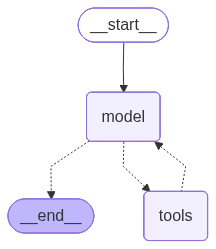

In [9]:
agent 

### 关键收获：
- `create_agent()` 可以用大约 10 行代码构建完整 Agent
- Agent 会自动处理“推理 -> 行动 -> 观察”的循环
- 基于 LangGraph 构建，具备生产级能力（持久化、流式输出、人在回路）


## 第 5 部分：添加记忆与状态

目前每次 Agent 调用都是相互独立的。我们来添加**记忆**，让 Agent 可以在多次交互之间保留上下文。

LangGraph 使用 **checkpointer（检查点保存器）** 来保存和恢复状态：


In [10]:
from langgraph .checkpoint .memory import MemorySaver 
from langsmith import uuid7 

# 创建用于记忆的 checkpointer
checkpointer =MemorySaver ()

# 创建带记忆的 Agent
agent_with_memory =create_agent (
model =model ,
tools =[get_weather ,search_movies ],
system_prompt ="你是一位乐于助人的助手。",
checkpointer =checkpointer 
)

# 为这段对话创建一个线程
config ={"configurable":{"thread_id":uuid7 ()}}

# 第一次交互
result1 =agent_with_memory .invoke (
{"messages":[{"role":"user","content":'我叫 Alice，我喜欢科幻电影。'}]},
config =config 
)

print ("回复 1：",result1 ["messages"][-1 ].content )

# 第二次交互：Agent 会记得前面的信息！
result2 =agent_with_memory .invoke (
{"messages":[{"role":"user","content":"我叫什么名字？我喜欢什么类型的电影？"}]},
config =config 
)
print ("\n回复 2：",result2 ["messages"][-1 ].content )


Response 1: Here are some great sci-fi movies for you, Alice! 🚀

1. **Dune** – A epic sci-fi adventure set in a vast desert world.
2. **Interstellar** – A mind-bending journey through space and time.
3. **Blade Runner 2049** – A visually stunning cyberpunk mystery.

Would you like me to check the weather for your location or help with anything else?

Response 2: Your name is **Alice**, and you love **sci-fi movies**! 🎥✨ 

Based on that, here are some great sci-fi recommendations I found earlier: **Dune**, **Interstellar**, and **Blade Runner 2049**. Would you like to explore any of these further?


### 理解状态与线程

- **State（状态）**：Agent 的“记忆”，包含消息历史以及自定义数据
- **Thread（线程）**：由 `thread_id` 标识的一次对话会话
- **Checkpointer（检查点保存器）**：在每一步之后保存状态，从而支持记忆和错误恢复

每个线程都是独立的：


In [ ]:
# 新线程：Agent 不会记得 Alice
new_config_with_new_thread_id ={"configurable":{"thread_id":uuid7 ()}}

result3 =agent_with_memory .invoke (
{"messages":[{"role":"user","content":"我叫什么名字？"}]},
config =new_config_with_new_thread_id 
)
print ("新线程回复：",result3 ["messages"][-1 ].content )


### 关键收获：
- Checkpointer 让 Agent 可以跨多次交互保留记忆
- Thread ID 用来区分不同对话
- 状态会自动持久化，不需要手动管理！


## 第 6 部分：用流式输出改善用户体验

LLM 生成回复可能需要一些时间。**Streaming（流式输出）** 可以实时展示进度，显著改善用户体验。

LangChain 支持多种流式模式：


### 流式输出 Agent 步骤

In [11]:
# 使用 stream_mode="updates" 流式输出 Agent 进度
print ('流式输出 Agent 步骤：\n')

for chunk in agent .stream (
{"messages":[{"role":"user","content":"波士顿天气怎么样？（北纬 42.36°、西经 71.06°）"}]},
stream_mode ="updates"
):
    for node_name ,data in chunk .items ():
        print (f"步骤：{node_name}")
        if "messages"in data :
            message =data ["messages"][-1 ]
            if hasattr (message ,'tool_calls')and message .tool_calls :
                print (f"   工具调用：{message.tool_calls[0]['name']}")
            elif hasattr (message ,'content'):
                print (f"   内容：{message.content[:100]}..."if len (message .content )>100 else f"   内容：{message.content}")
        print ()


Streaming agent steps:

Step: model
   Tool call: get_weather

Step: tools
   Content: {"temperature_fahrenheit": 63.9, "weather_code": 0}

Step: model
   Content: The weather in **Boston** right now is **63.9°F** with **clear skies**. It's a pleasant day! 🌤️

Wou...



### 流式输出 LLM token

如果想要类似 ChatGPT 的体验，可以在 token 生成时逐步输出：


In [13]:
# 使用 stream_mode="messages" 流式输出 token
print ('流式输出 token：\n')

for token ,metadata in agent .stream (
{"messages":[{"role":"user","content":'用一句话介绍 LangGraph。'}]},
stream_mode ="messages"
):
# 只打印 model 节点输出的内容
    if metadata .get ('langgraph_node')=='model':
    # 从 content blocks 中提取文本
        for block in token .content_blocks :
            if block .get ('type')=='text'and block .get ('text'):
                print (block ['text'],end ='',flush =True )

print ("\n")# 结尾换行


Streaming tokens:

LangGraph is a library from LangChain that enables building stateful, multi-actor applications with LLMs by modeling them as graphs of nodes (functions) and edges (control flow).



### 关键收获：
- `stream_mode="updates"`：查看每个 Agent 步骤（适合调试）
- `stream_mode="messages"`：流式输出 LLM token（类似 ChatGPT 的体验）
- 流式能力是内置的，不需要额外配置！


## 第 7 部分：整合起来：一个实用示例

我们来构建一个更接近真实场景的 Agent，把前面学到的内容组合起来：


In [ ]:
# 创建更接近真实场景的工具
@tool 
def get_user_preferences (user_id :str )->str :
    """获取用户保存过的偏好。"""
    # 模拟用户数据库
    preferences ={
    "alice":"喜欢科幻电影，偏好温暖天气的旅行目的地",
    "bob":"喜欢喜剧电影，旅行时偏好寒冷气候"
    }
    return preferences .get (user_id .lower (),"没有找到偏好记录")

@tool 
def book_recommendation (genre :str ,user_preferences :str ="")->str :
    """根据类型和用户偏好获取个性化电影推荐。"""
    recommendations ={
    "科幻":"根据你的偏好，可以试试：《降临》《机械姬》或《火星救援》",
    "喜剧":"根据你的偏好，可以试试：《谋杀绿脚趾》《王牌播音员》或《伴娘》",
    "sci-fi":"根据你的偏好，可以试试：《降临》《机械姬》或《火星救援》",
    "comedy":"根据你的偏好，可以试试：《谋杀绿脚趾》《王牌播音员》或《伴娘》",
    }
    return recommendations .get (genre .lower (),"暂无可用推荐")

    # 创建一个乐于助人的个人助手 Agent
assistant =create_agent (
model =model ,
tools =[get_weather ,get_user_preferences ,book_recommendation ],
system_prompt ="""你是一位乐于助人的个人助手。

    你可以：
    - 查询任意城市的天气
    - 查询用户偏好
    - 根据偏好推荐电影

    请始终保持友好，并根据用户偏好提供个性化回复。""",
checkpointer =MemorySaver ()
)

# 演示对话
config ={"configurable":{"thread_id":uuid7 ()}}

print ("="*50 )
print ("个人助手演示")
print ("="*50 +"\n")

# 第 1 次交互
print ('用户：你好，我是 Alice。可以帮我查看偏好并推荐一部电影吗？\n')
result =assistant .invoke (
{"messages":[{"role":"user","content":'你好，我是 Alice。可以帮我查看偏好并推荐一部电影吗？'}]},
config =config 
)
print (f"助手：{result['messages'][-1].content}\n")

# 第 2 次交互
print ("用户：另外，旧金山天气怎么样？（北纬 37.77°、西经 122.42°）\n")
result =assistant .invoke (
{"messages":[{"role":"user","content":"另外，旧金山天气怎么样？（北纬 37.77°、西经 122.42°）"}]},
config =config 
)
print (f"助手：{result['messages'][-1].content}\n")

print ("="*50 )


## 第 8 部分：下一步：探索 LangGraph 原语

前面我们一直在使用 `create_agent()`，它本身是基于 **LangGraph** 构建的。LangGraph 提供三个核心原语，让你可以完全控制 Agent 的行为：

### LangGraph 核心概念：

1. **State（状态）** 
   - 在节点之间传递的共享数据结构
   - 表示 Agent 的“记忆”
   - 可以包含消息、自定义数据等

2. **Nodes（节点）** 
   - 处理状态的 Python 函数
   - 每个节点执行一个具体任务
   - 例如：调用 LLM、执行工具、校验输入

3. **Edges（边）** 
   - 定义节点之间的流向
   - 可以是普通边（始终进入下一个节点）
   - 也可以是条件边（根据逻辑决定下一步）


### 什么时候使用 `create_agent()`，什么时候自定义 LangGraph？

**适合使用 `create_agent()` 的情况：**
- 构建标准 ReAct 风格 Agent
- 需要快速原型验证
- 默认行为已经满足你的使用场景

**适合自定义 LangGraph 的情况：**
- 需要自定义控制流（例如审批工作流）
- 构建多 Agent 系统
- 实现人在回路模式
- 有复杂的状态管理需求

想了解更多高级模式，可以查看：
- [LangGraph 文档](https://langchain-ai.github.io/langgraph/)
- [LangChain Academy](https://academy.langchain.com/)
- 本仓库中的 `multi_agent.ipynb` notebook（LangGraph 201）


## 从零构建一个 ReAct Agent

为了理解 LangGraph 原语是如何工作的，我们来重新构建前面创建过的 Agent，但这次不使用 `create_agent()`。

### 状态

我们的聊天机器人很简单：它只是一个带有若干工具的 LLM。因此，状态里只需要保存一个消息列表，包含用户消息、AI 消息和工具消息，并随着对话进行不断增长。 


In [ ]:
from typing_extensions import TypedDict 
from typing import Annotated ,List 
from langgraph .graph .message import AnyMessage ,add_messages 
from langgraph .managed .is_last_step import RemainingSteps 

class State (TypedDict ):
# 包含完整对话历史，并随着对话推进不断增长
    messages :Annotated [List [AnyMessage ],add_messages ]


### 节点

我们可以复用前面定义过的工具。不过，还需要创建一个节点来处理工具调用，并把结果格式化成 LLM 能理解的 `ToolMessage` 对象。这里不自己实现这个节点，而是使用 LangGraph 预构建的 `ToolNode`。


In [ ]:
from langgraph .prebuilt import ToolNode 
# 节点
tools =[search_movies ,get_weather ]
tool_node =ToolNode (tools )


现在，我们来为主助手创建节点。

In [ ]:
def assistant (state :State ):
# 创建要发送给 LLM 的消息列表，并以固定系统提示词开头
    system_prompt ="你是一位乐于助人的助手，可以查询天气并推荐电影。"
    all_messages =[SystemMessage (system_prompt )]+state ["messages"]
    # 调用 LLM
    response =model_with_tools .invoke (all_messages )
    # 用 LLM 的回复更新状态
    return {"messages":[response ]}


现在需要定义连接这些节点的控制流，也就是 Edges（边）的概念。

**Edges 是节点之间的连接，它们定义图的流向。**
* **普通边** 是确定性的，总是从一个节点流向指定目标节点
* **条件边** 用于在节点之间动态路由，通常实现为一个函数，根据某些逻辑返回下一步要访问的节点

在这个例子里，我们希望从子 Agent 出发有一条**条件边**，用于判断：
- 调用工具；或者
- 如果用户查询已经完成，则路由到结束节点


In [ ]:
# 条件边：判断是否继续执行

def should_continue (state :State ):
    messages =state ["messages"]
    last_message =messages [-1 ]
    # 如果 LLM 想调用工具，就执行工具并继续
    if last_message .tool_calls :
        return "continue"
        # 如果 LLM 返回的是普通回复而不是工具调用，流程结束
    else :
        return "end"


#### 编译图！

现在已经定义好了状态、节点和条件边，我们把它们组合起来，构建这个 ReAct Agent！


In [ ]:
from langgraph .graph import StateGraph ,START ,END 

# 首先用 State 类定义 builder
builder =StateGraph (State )

# 添加节点
builder .add_node ("assistant",assistant )
builder .add_node ("tool_node",tool_node )


# 添加边
# 首先定义起始节点。用户查询总是先路由到 assistant 节点。
builder .add_edge (START ,"assistant")

# 在调用 LLM 之后添加条件边
builder .add_conditional_edges (
"assistant",
should_continue ,
{
# 如果返回 `continue`，就调用工具节点。
"continue":"tool_node",
# 否则流程结束。
"end":END ,
},
)

# 调用工具后始终回到 LLM
builder .add_edge ("tool_node","assistant")

agent =builder .compile (name ="agent")
agent 


我们已经成功从零重建了一个 ReAct Agent，它和前面使用 `create_agent` 创建的基础 Agent 功能相同。试试看！


In [ ]:
from langchain .messages import HumanMessage 

question ="今天旧金山天气怎么样（北纬 37.77°、西经 122.42°）？另外有哪些不错的科幻电影？"

result =agent .invoke ({"messages":HumanMessage (content =question )})

for message in result ["messages"]:
    message .pretty_print ()


## 恭喜！

你已经学会了使用 LangChain 和 LangGraph 构建 Agent 的核心概念：

 **Models（模型）**：跨供应商的标准化接口  
 **Messages（消息）**：构建对话的基本单元  
 **Tools（工具）**：扩展 LLM 能力  
 **Agents（智能体）**：自动化推理与行动循环  
 **Memory（记忆）**：跨交互保留上下文  
 **Streaming（流式输出）**：实时用户体验  
 **LangGraph**：支撑这一切的底层基础

### 下一步？

1. 使用你的具体工具和场景，**构建自己的 Agent**
2. 在 `multi_agent.ipynb` notebook 中**探索高级模式**
3. 使用 [LangSmith](https://smith.langchain.com) **添加调试能力**
4. 利用 LangGraph 的持久化和错误恢复能力**部署到生产环境**

### 资源：

- [LangChain 文档](https://python.langchain.com/docs/introduction/)
- [LangGraph 文档](https://langchain-ai.github.io/langgraph/)
- [LangSmith 调试平台](https://smith.langchain.com)
- [LangChain Academy](https://academy.langchain.com/)
<br> 
<br> 
---
<br> 

**祝你构建愉快！**
